In [1]:
!pip install -q sahi
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.9 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import cv2
import random
import shutil
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from sahi.utils.cv import visualize_object_predictions

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
MODEL_PATH = "/kaggle/input/datasets/aadeeshranjansriv/yolov8s/best.pt"

VAL_IMAGES = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images"

LABEL_DIR = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels"

print("CUDA:", torch.cuda.is_available())

CUDA: True


In [4]:
detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=MODEL_PATH,
    confidence_threshold=0.25,
    device="cuda"
)

model = YOLO(MODEL_PATH)

In [5]:
labeled_images = []

for label_file in os.listdir(LABEL_DIR):
    if os.path.getsize(os.path.join(LABEL_DIR, label_file)) > 0:
        labeled_images.append(
            label_file.replace(".txt", ".jpg")
        )

print("Labeled Images:", len(labeled_images))

Labeled Images: 3921


In [12]:
sample_images = random.sample(
    labeled_images,
    5
)
sample_images

['Japan_009423.jpg',
 'India_004917.jpg',
 'Japan_007805.jpg',
 'China_Drone_000866.jpg',
 'Japan_010190.jpg']

In [13]:
os.makedirs("thesis_examples", exist_ok=True)

In [14]:
for image_name in sample_images:

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    result = get_sliced_prediction(
        image_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )

    result.export_visuals(
        export_dir="thesis_examples",
        file_name=image_name.replace(".jpg", "")
    )

    print(f"Processed: {image_name}")

Performing prediction on 4 slices.
Processed: Japan_009423.jpg
Performing prediction on 4 slices.
Processed: India_004917.jpg
Performing prediction on 4 slices.
Processed: Japan_007805.jpg
Performing prediction on 1 slices.
Processed: China_Drone_000866.jpg
Performing prediction on 4 slices.
Processed: Japan_010190.jpg


In [15]:
os.listdir("thesis_examples")

['Japan_009423.png',
 'Japan_007805.png',
 'Japan_010190.png',
 'China_Drone_000866.png',
 'India_004917.png']

China_Drone_000866.png


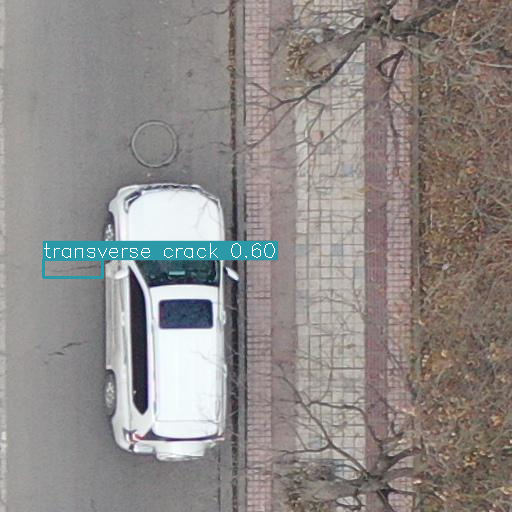

India_004917.png


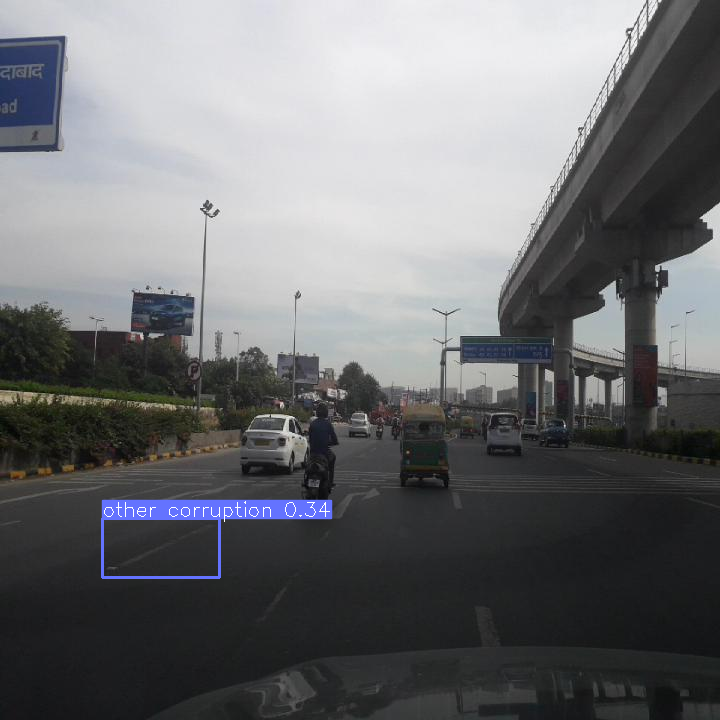

Japan_007805.png


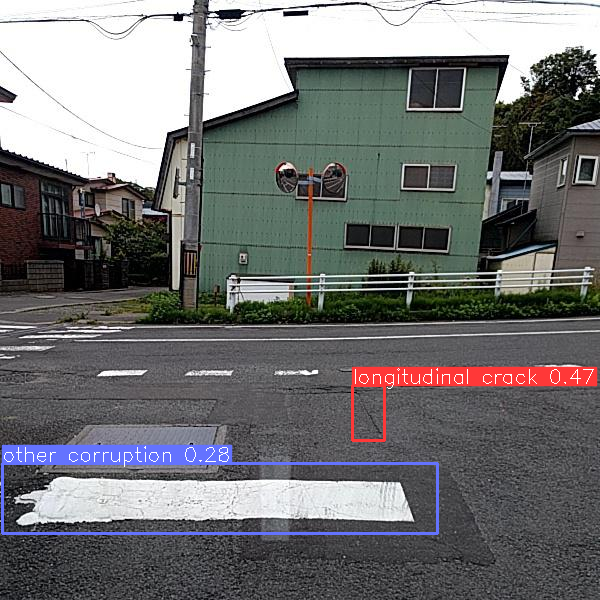

Japan_009423.png


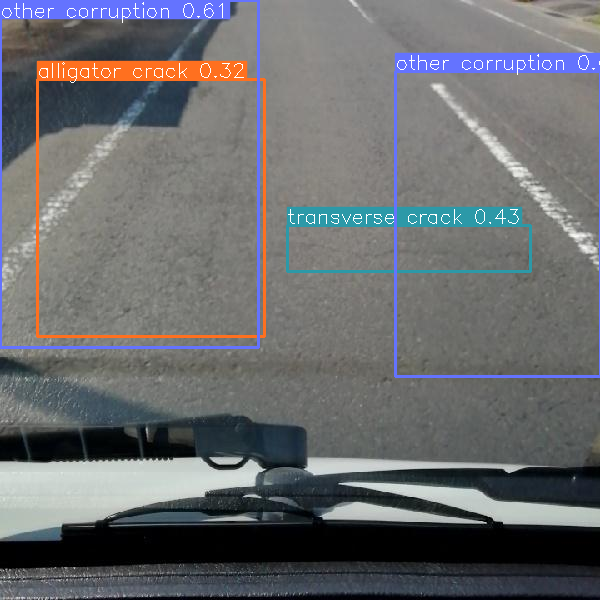

Japan_010190.png


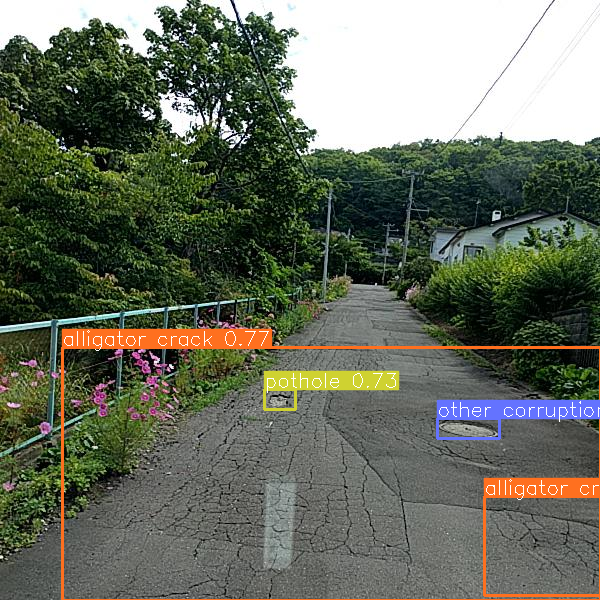

In [16]:
from PIL import Image
from IPython.display import display

for img in sorted(os.listdir("thesis_examples")):
    print(img)
    display(Image.open(os.path.join("thesis_examples", img)))

In [17]:
candidate_images = []

evaluation_subset = random.sample(
    labeled_images,
    300
)

for image_name in evaluation_subset:

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    yolo_count = len(
        model(
            image_path,
            verbose=False
        )[0].boxes
    )

    sahi_count = len(
        get_sliced_prediction(
            image_path,
            detection_model,
            slice_height=512,
            slice_width=512,
            overlap_height_ratio=0.2,
            overlap_width_ratio=0.2
        ).object_prediction_list
    )

    gain = sahi_count - yolo_count

    candidate_images.append({
        "image_path": image_path,
        "yolo": yolo_count,
        "sahi": sahi_count,
        "gain": gain
    })

candidate_images = sorted(
    candidate_images,
    key=lambda x: x["gain"],
    reverse=True
)

candidate_images[:10]

Performing prediction on 4 slices.
Performing prediction on 50 slices.
Performing prediction on 50 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 45 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing predic

[{'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_007247.jpg',
  'yolo': 0,
  'sahi': 12,
  'gain': 12},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_007337.jpg',
  'yolo': 2,
  'sahi': 13,
  'gain': 11},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_000994.jpg',
  'yolo': 5,
  'sahi': 15,
  'gain': 10},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_004934.jpg',
  'yolo': 0,
  'sahi': 9,
  'gain': 9},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_001828.jpg',
  'yolo': 0,
  'sahi': 9,
  'gain': 9},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_003330.jpg',
  'yolo': 0,
  'sahi': 8,
  'gain': 8},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_003039.jpg',
  'yolo': 4,
  'sahi': 12,

In [23]:
import os
import shutil

shutil.rmtree(
    "top_gain_comparisons",
    ignore_errors=True
)

os.makedirs(
    "top_gain_comparisons",
    exist_ok=True
)

print("Folder ready")

Folder ready


In [24]:
top_images = candidate_images[:5]

for idx, item in enumerate(
    top_images,
    start=1
):

    image_path = item["image_path"]

    yolo_result = model(
        image_path,
        verbose=False
    )[0]

    yolo_img = yolo_result.plot()

    sahi_result = get_sliced_prediction(
        image_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )

    original = cv2.imread(
        image_path
    )

    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    vis = visualize_object_predictions(
        image=original,
        object_prediction_list=sahi_result.object_prediction_list,
        output_dir=None
    )

    sahi_img = vis["image"]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12,6)
    )

    axes[0].imshow(
        cv2.cvtColor(
            yolo_img,
            cv2.COLOR_BGR2RGB
        )
    )

    axes[0].set_title(
        f"YOLO ({item['yolo']})"
    )

    axes[0].axis("off")

    axes[1].imshow(
        sahi_img
    )

    axes[1].set_title(
        f"SAHI ({item['sahi']})"
    )

    axes[1].axis("off")

    plt.tight_layout()

    plt.savefig(
        f"top_gain_comparisons/top_gain_{idx}.png",
        dpi=300
    )

    plt.close()

Performing prediction on 45 slices.
Performing prediction on 45 slices.
Performing prediction on 45 slices.
Performing prediction on 45 slices.
Performing prediction on 45 slices.


In [25]:
for idx, item in enumerate(top_images, start=1):

    print(
        f"{idx}.",
        os.path.basename(item['image_path']),
        f"YOLO={item['yolo']}",
        f"SAHI={item['sahi']}",
        f"Gain={item['gain']}"
    )

1. Norway_007247.jpg YOLO=0 SAHI=12 Gain=12
2. Norway_007337.jpg YOLO=2 SAHI=13 Gain=11
3. Norway_000994.jpg YOLO=5 SAHI=15 Gain=10
4. Norway_004934.jpg YOLO=0 SAHI=9 Gain=9
5. Norway_001828.jpg YOLO=0 SAHI=9 Gain=9


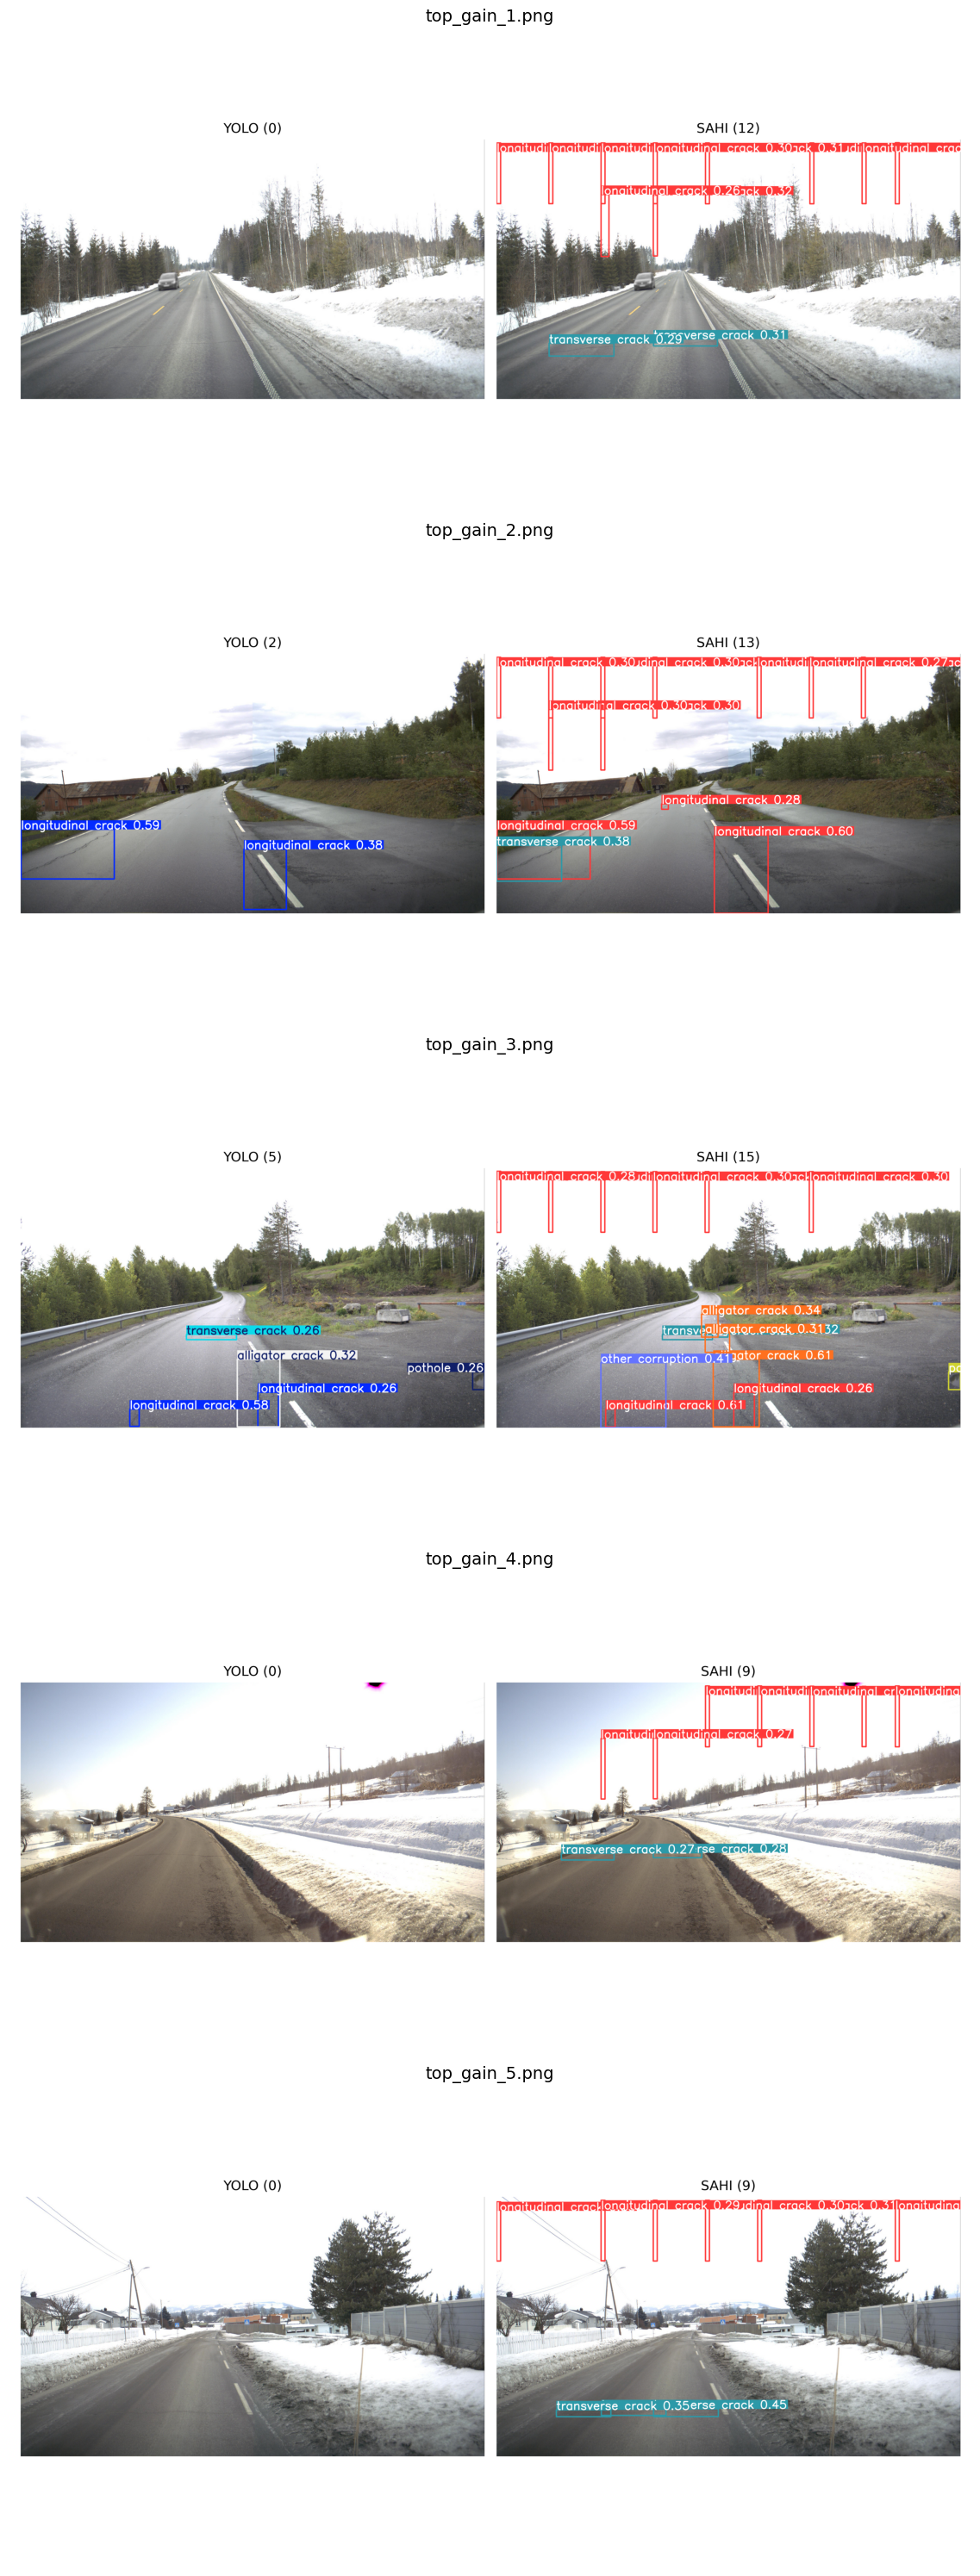

In [26]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

comparison_files = sorted(
    os.listdir("top_gain_comparisons")
)

fig, axes = plt.subplots(
    len(comparison_files),
    1,
    figsize=(14, 6 * len(comparison_files))
)

if len(comparison_files) == 1:
    axes = [axes]

for ax, file in zip(axes, comparison_files):

    img = mpimg.imread(
        os.path.join(
            "top_gain_comparisons",
            file
        )
    )

    ax.imshow(img)
    ax.set_title(file, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [27]:
subset_images = random.sample(
    labeled_images,
    2000
)

total_yolo = 0
total_sahi = 0

for image_name in subset_images:

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    total_yolo += len(
        model(
            image_path,
            verbose=False
        )[0].boxes
    )

    total_sahi += len(
        get_sliced_prediction(
            image_path,
            detection_model,
            slice_height=512,
            slice_width=512,
            overlap_height_ratio=0.2,
            overlap_width_ratio=0.2
        ).object_prediction_list
    )

improvement = (
    (total_sahi - total_yolo)
    / total_yolo
) * 100

print("YOLOv8n detections:", total_yolo)
print("SAHI detections:", total_sahi)
print(f"Improvement: {improvement:.2f}%")

Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 45 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 45 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 45 slices.
Performing prediction on 9 slices.
Performing predic

In [29]:
with open("evaluation_summary.txt", "w") as f:
    f.write("Model: YOLOv8s + SAHI\n\n")
    f.write("Images Evaluated: 2000\n\n")
    f.write("YOLOv8s Detections: 4237\n")
    f.write("SAHI Detections: 5475\n")
    f.write("Improvement (%): 29.22\n")

In [30]:
!zip -r yolov8s_sahi_results.zip \
    thesis_examples \
    top_gain_comparisons \
    evaluation_summary.txt

  adding: thesis_examples/ (stored 0%)
  adding: thesis_examples/Japan_009423.png (deflated 13%)
  adding: thesis_examples/Japan_007805.png (deflated 9%)
  adding: thesis_examples/Japan_010190.png (deflated 4%)
  adding: thesis_examples/China_Drone_000866.png (deflated 6%)
  adding: thesis_examples/India_004917.png (deflated 14%)
  adding: top_gain_comparisons/ (stored 0%)
  adding: top_gain_comparisons/top_gain_1.png (deflated 2%)
  adding: top_gain_comparisons/top_gain_5.png (deflated 3%)
  adding: top_gain_comparisons/top_gain_3.png (deflated 2%)
  adding: top_gain_comparisons/top_gain_4.png (deflated 3%)
  adding: top_gain_comparisons/top_gain_2.png (deflated 3%)
  adding: evaluation_summary.txt (deflated 16%)


In [31]:
!ls -lh *.zip

-rw-r--r-- 1 root root 12M Jun 14 10:39 yolov8s_sahi_results.zip


In [6]:
SAHI_PRED_DIR = "/kaggle/working/sahi_predictions"

if os.path.exists(SAHI_PRED_DIR):
    shutil.rmtree(SAHI_PRED_DIR)

os.makedirs(
    os.path.join(SAHI_PRED_DIR, "labels"),
    exist_ok=True
)

print("Prediction directory ready.")

Prediction directory ready.


In [7]:
import os
import json
from PIL import Image

COCO_GT_PATH = "/kaggle/working/instances_val.json"

categories = [
    {"id": 1, "name": "Longitudinal Crack"},
    {"id": 2, "name": "Transverse Crack"},
    {"id": 3, "name": "Alligator Crack"},
    {"id": 4, "name": "Other Corruption"},
    {"id": 5, "name": "Pothole"},
]

# ALL validation images (including backgrounds)
all_images = sorted([
    f for f in os.listdir(VAL_IMAGES)
    if f.endswith(".jpg")
])

images = []
annotations = []

annotation_id = 1

for image_name in all_images:

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    label_path = os.path.join(
        LABEL_DIR,
        image_name.replace(".jpg", ".txt")
    )

    width, height = Image.open(image_path).size

    image_id = image_name.replace(".jpg", "")

    images.append({
        "id": image_id,
        "file_name": image_name,
        "width": width,
        "height": height
    })

    if not os.path.exists(label_path):
        continue

    with open(label_path) as f:

        for line in f:

            cls, xc, yc, bw, bh = map(float, line.split())

            x = (xc - bw / 2) * width
            y = (yc - bh / 2) * height
            w = bw * width
            h = bh * height

            annotations.append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": int(cls) + 1,
                "bbox": [x, y, w, h],
                "area": w * h,
                "iscrowd": 0
            })

            annotation_id += 1

coco_gt = {
    "images": images,
    "annotations": annotations,
    "categories": categories
}

with open(COCO_GT_PATH, "w") as f:
    json.dump(coco_gt, f)

print("Saved:", COCO_GT_PATH)
print("Images:", len(images))
print("Annotations:", len(annotations))

Saved: /kaggle/working/instances_val.json
Images: 5758
Annotations: 9741


In [8]:
test_image = os.path.join(
    VAL_IMAGES,
    labeled_images[0]
)

result = get_sliced_prediction(
    test_image,
    detection_model,
    slice_height=512,
    slice_width=512,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
    verbose=0
)

print(type(result.object_prediction_list))

pred = result.object_prediction_list[0]

print(type(pred))
print(pred)

<class 'list'>
<class 'sahi.prediction.ObjectPrediction'>
ObjectPrediction<
    bbox: BoundingBox: <(0, 316.1753845214844, 468.4653015136719, 474.1114807128906), w: 468.4653015136719, h: 157.93609619140625>,
    mask: None,
    score: PredictionScore: <value: 0.5104607939720154>,
    category: Category: <id: 0, name: longitudinal crack>>


In [9]:
print(pred.bbox.to_xyxy())
print(pred.bbox.to_xywh())

[0, 316.1753845214844, 468.4653015136719, 474.1114807128906]
[0, 316.1753845214844, 468.4653015136719, 157.93609619140625]


In [10]:
import json
from tqdm import tqdm
from sahi.predict import get_sliced_prediction

COCO_PRED_PATH = "/kaggle/working/predictions.json"

predictions = []

for image_name in tqdm(all_images):

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    result = get_sliced_prediction(
        image_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
        verbose=0
    )

    image_id = image_name.replace(".jpg", "")

    for pred in result.object_prediction_list:

        x, y, w, h = pred.bbox.to_xywh()

        predictions.append({

            "image_id": image_id,

            "category_id": int(pred.category.id) + 1,

            "bbox": [
                float(x),
                float(y),
                float(w),
                float(h)
            ],

            "score": float(pred.score.value)

        })

with open(COCO_PRED_PATH, "w") as f:
    json.dump(predictions, f)

print(f"Saved predictions to {COCO_PRED_PATH}")
print(f"Total predictions: {len(predictions)}")

100%|██████████| 5758/5758 [24:39<00:00,  3.89it/s]


Saved predictions to /kaggle/working/predictions.json
Total predictions: 13354


In [11]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

coco_gt = COCO(COCO_GT_PATH)

coco_dt = coco_gt.loadRes(COCO_PRED_PATH)

coco_eval = COCOeval(
    coco_gt,
    coco_dt,
    iouType="bbox"
)

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.24s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.55s).
Accumulating evaluation results...
DONE (t=0.53s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.218
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.441
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.189
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.131
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.186
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.233
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.239
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.312
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [12]:
import pandas as pd

summary = {
    "Precision": coco_eval.stats[1],   # AP@50
    "Recall": coco_eval.stats[8],      # AR@100
    "mAP50": coco_eval.stats[1],
    "mAP50_95": coco_eval.stats[0]
}

df = pd.DataFrame([summary])

df.to_csv("sahi_metrics.csv", index=False)

display(df)

,Precision,Recall,mAP50,mAP50_95
0,0.44113,0.311994,0.44113,0.218373
